In [1]:
import os
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from joblib import Parallel, delayed

# Make both the repository root and the Diffusion module discoverable when the
# notebook is executed from different working directories.
cwd = pathlib.Path().resolve()
repo_root = cwd if (cwd / 'XYModel').exists() else cwd.parent
for path in [repo_root, repo_root / 'Diffusion']:
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

from diffusion_map import diffusion_map, compute_eigendecomposition, construct_transition_matrix, compute_gaussian_kernel, construct_diffusion_map_embedding
from XYModel.xy import XYModelMetropolisSimulation

try:
    import torch
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    use_gpu = torch.cuda.is_available()
    print(f"Using torch device: {device}")
except ImportError:
    torch = None
    device = 'cpu'
    use_gpu = False
    print('PyTorch not installed; falling back to CPU.')


Using torch device: cuda


In [16]:
from numba import jit

@jit(nopython=True)
def compute_winding_numbers(theta, L):
    """
    Compute winding numbers (nu_x, nu_y) for a 2D XY configuration.
    
    Parameters:
    -----------
    theta : array (L, L)
        Spin angles on the lattice
    L : int
        Lattice size
        
    Returns:
    --------
    nu_x, nu_y : floats
        Winding numbers along x and y directions
    """
                                                           
    wind_x = 0.0
    for j in range(L):
        for i in range(L):
            i_next = (i + 1) % L
            delta = theta[j, i_next] - theta[j, i]
                               
            while delta > np.pi:
                delta -= 2 * np.pi
            while delta < -np.pi:
                delta += 2 * np.pi
            wind_x += delta
    
                                                         
    wind_y = 0.0
    for i in range(L):
        for j in range(L):
            j_next = (j + 1) % L
            delta = theta[j_next, i] - theta[j, i]
                               
            while delta > np.pi:
                delta -= 2 * np.pi
            while delta < -np.pi:
                delta += 2 * np.pi
            wind_y += delta
    
    return wind_x / (2 * np.pi), wind_y / (2 * np.pi)

                                     
print("Testing winding number computation...")
test_theta = np.random.uniform(0, 2*np.pi, (32, 32))
nu_x, nu_y = compute_winding_numbers(test_theta, 32)
print(f"Random configuration: nu_x = {nu_x:.3f}, nu_y = {nu_y:.3f}")


Testing winding number computation...
Random configuration: nu_x = 0.000, nu_y = -3.000


In [17]:

                                               
@jit(nopython=True)
def compute_energy(theta, L, J=1.0):
    """Compute total energy of the XY configuration."""
    energy = 0.0
    for i in range(L):
        for j in range(L):
                                                                 
            i_next = (i + 1) % L
            j_next = (j + 1) % L
            
                                                
            energy -= J * np.cos(theta[i, j] - theta[i_next, j])
            energy -= J * np.cos(theta[i, j] - theta[i, j_next])
    
    return energy

@jit(nopython=True)
def metropolis_step(theta, L, beta, J=1.0):
    """Perform one Metropolis Monte Carlo sweep."""
    for _ in range(L * L):
                     
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        
                       
        theta_old = theta[i, j]
        
                           
        theta_new = np.random.uniform(0, 2 * np.pi)
        
                                                          
        i_prev = (i - 1) % L
        i_next = (i + 1) % L
        j_prev = (j - 1) % L
        j_next = (j + 1) % L
        
        delta_E = 0.0
                                  
        delta_E += J * np.cos(theta_old - theta[i_next, j])
        delta_E += J * np.cos(theta_old - theta[i_prev, j])
        delta_E += J * np.cos(theta_old - theta[i, j_next])
        delta_E += J * np.cos(theta_old - theta[i, j_prev])
        
                                  
        delta_E -= J * np.cos(theta_new - theta[i_next, j])
        delta_E -= J * np.cos(theta_new - theta[i_prev, j])
        delta_E -= J * np.cos(theta_new - theta[i, j_next])
        delta_E -= J * np.cos(theta_new - theta[i, j_prev])
        
                               
        if delta_E < 0 or np.random.random() < np.exp(-beta * delta_E):
            theta[i, j] = theta_new
    
    return theta

print("Monte Carlo functions defined successfully.")
print("Testing energy computation...")
test_theta = np.random.uniform(0, 2*np.pi, (32, 32))
energy = compute_energy(test_theta, 32)
print(f"Random configuration energy: {energy:.2f}")


Monte Carlo functions defined successfully.
Testing energy computation...
Random configuration energy: -4.21


In [20]:
@jit(nopython=True)
def initialize_with_winding(L, nu_x, nu_y):
    """
    Initialize a 2D XY configuration with the desired winding numbers by
    imposing linear phase twists in x and y.
    """
    theta = np.zeros((L, L))
    for j in range(L):
        for i in range(L):
            phase = 2 * np.pi * ((nu_x * i) / L + (nu_y * j) / L)
            theta[j, i] = np.mod(phase, 2 * np.pi)
    return theta
                                

@jit(nopython=True)
def compute_winding_numbers_correct(theta, L):
    """
    Compute winding numbers (nu_x, nu_y) for a 2D XY configuration.
    The winding number is the net phase accumulated around one loop of the torus.
    """
                                                       
    wind_x = 0.0
    for i in range(L):
        i_next = (i + 1) % L
        delta = theta[0, i_next] - theta[0, i]
                           
        while delta > np.pi:
            delta -= 2 * np.pi
        while delta < -np.pi:
            delta += 2 * np.pi
        wind_x += delta
    
                                                          
    wind_y = 0.0
    for j in range(L):
        j_next = (j + 1) % L
        delta = theta[j_next, 0] - theta[j, 0]
                           
        while delta > np.pi:
            delta -= 2 * np.pi
        while delta < -np.pi:
            delta += 2 * np.pi
        wind_y += delta
    
    return wind_x / (2 * np.pi), wind_y / (2 * np.pi)

                               
print("Testing corrected winding number computation...")
for target_nu_x, target_nu_y in [(0, 0), (1, 0), (0, 1), (-1, 0), (-1, -1)]:
    test_theta = initialize_with_winding(32, target_nu_x, target_nu_y)
    nu_x, nu_y = compute_winding_numbers_correct(test_theta, 32)
    print(f"Target: ({target_nu_x:2d}, {target_nu_y:2d}) -> Actual: ({nu_x:6.3f}, {nu_y:6.3f})")


Testing corrected winding number computation...
Target: ( 0,  0) -> Actual: ( 0.000,  0.000)
Target: ( 1,  0) -> Actual: ( 1.000,  0.000)
Target: ( 0,  1) -> Actual: ( 0.000,  1.000)
Target: (-1,  0) -> Actual: (-1.000,  0.000)
Target: (-1, -1) -> Actual: (-1.000, -1.000)


In [54]:
@jit(nopython=True)
def generate_configuration(L, nu_x, nu_y, beta, J=1.0, 
                          thermalization_sweeps=1000, 
                          decorrelation_sweeps=50):
    """
    Generate a thermalized configuration with specified winding numbers.
    
    Parameters:
    -----------
    L : int
        Lattice size
    nu_x, nu_y : int
        Target winding numbers
    beta : float
        Inverse temperature (1/T)
    J : float
        Coupling constant (default 1.0)
    thermalization_sweeps : int
        Number of MC sweeps for thermalization
    decorrelation_sweeps : int
        Number of MC sweeps between measurements
        
    Returns:
    --------
    theta : array (L, L)
        Thermalized spin configuration
    """
    while True: 
        theta = initialize_with_winding(L, nu_x, nu_y)
        for _ in range(thermalization_sweeps):
            theta = metropolis_step(theta, L, beta, J)
        
                                
        for _ in range(decorrelation_sweeps):
            theta = metropolis_step(theta, L, beta, J)

        if compute_winding_numbers_correct(theta, L) == (nu_x, nu_y):
            break
    return theta

                               
print("Testing configuration generation...")
test_config = generate_configuration(32, 1, 0, beta=1/0.9, 
                                    thermalization_sweeps=40, 
                                    decorrelation_sweeps=10)
nu_x, nu_y = compute_winding_numbers_correct(test_config, 32)
print(f"Generated config with target (1, 0): actual ({nu_x:.3f}, {nu_y:.3f})")
print(f"Configuration shape: {test_config.shape}")


Testing configuration generation...
Generated config with target (1, 0): actual (1.000, 0.000)
Configuration shape: (32, 32)


In [67]:
import time

L = 32
temperatures = np.array([1.2])
topological_sectors = [(0, 0), (1, 0), (0, 1), (-1, 0), (0, -1)]
samples_per_sector = 1000
# Reserve one core for the OS to keep the notebook responsive.
data_workers = max(1, (os.cpu_count() or 1) - 1)

def get_thermalization_params(T):
    """Return (thermalization_sweeps, decorrelation_sweeps) based on temperature."""
    if T < 0.5:
        return 200, 100
    elif T < 0.7:
        return 200, 100
    elif T < 0.9:
        return 200, 100
    else:
        return 200, 100

print("Dataset generation parameters:")
print(f"  Lattice size: {L}×{L} = {L*L} spins")
print(f"  Temperatures: {temperatures}")
print(f"  Topological sectors: {topological_sectors}")
print(f"  Samples per sector: {samples_per_sector}")
print(f"  Total configurations: {len(temperatures) * len(topological_sectors) * samples_per_sector}")
print(f"  Data generation workers: {data_workers}")
print("\nAdaptive thermalization:")
for T in temperatures:
    therm, decor = get_thermalization_params(T)
    print(f"  T = {T:.2f}: {therm} thermalization sweeps, {decor} decorrelation sweeps")


Dataset generation parameters:
  Lattice size: 32×32 = 1024 spins
  Temperatures: [1.2]
  Topological sectors: [(0, 0), (1, 0), (0, 1), (-1, 0), (0, -1)]
  Samples per sector: 1000
  Total configurations: 5000
  Data generation workers: 63

Adaptive thermalization:
  T = 1.20: 200 thermalization sweeps, 100 decorrelation sweeps


In [68]:
print("Starting dataset generation...")
print("=" * 80)

total_configs = len(temperatures) * len(topological_sectors) * samples_per_sector
configs_list = []
metadata_list = []

start_time = time.time()


def _generate_single(T, nu_x, nu_y, sample_idx):
    beta = 1.0 / T
    therm_sweeps, decor_sweeps = get_thermalization_params(T)
    config = generate_configuration(
        L,
        nu_x,
        nu_y,
        beta,
        thermalization_sweeps=therm_sweeps,
        decorrelation_sweeps=decor_sweeps,
    )
    metadata = {
        'temperature': T,
        'beta': beta,
        'nu_x': nu_x,
        'nu_y': nu_y,
        'sector_label': f"({nu_x},{nu_y})",
        'sample_idx': sample_idx,
    }
    return config.flatten(), metadata

jobs = [
    (T, nu_x, nu_y, sample_idx)
    for T in temperatures
    for (nu_x, nu_y) in topological_sectors
    for sample_idx in range(samples_per_sector)
]

results = Parallel(n_jobs=data_workers, prefer='processes', verbose=10)(
    delayed(_generate_single)(T, nu_x, nu_y, sample_idx)
    for (T, nu_x, nu_y, sample_idx) in jobs
)

for config_flat, meta in results:
    configs_list.append(config_flat)
    metadata_list.append(meta)

config_count = len(configs_list)
total_time = time.time() - start_time
print("\n" + "=" * 80)
print("Dataset generation complete!")
print(f"Total time: {total_time/60:.1f} minutes")
print(f"Configurations generated: {config_count}")
print(f"Average time per config: {total_time / max(config_count, 1):.2f} seconds")


Starting dataset generation...


[Parallel(n_jobs=63)]: Using backend LokyBackend with 63 concurrent workers.


[Parallel(n_jobs=63)]: Done   2 tasks      | elapsed:   18.5s
[Parallel(n_jobs=63)]: Done  19 tasks      | elapsed:   40.0s
[Parallel(n_jobs=63)]: Done  36 tasks      | elapsed:   57.9s
[Parallel(n_jobs=63)]: Done  55 tasks      | elapsed:  1.2min
[Parallel(n_jobs=63)]: Done  74 tasks      | elapsed:  1.6min
[Parallel(n_jobs=63)]: Done  95 tasks      | elapsed:  1.9min
[Parallel(n_jobs=63)]: Done 116 tasks      | elapsed:  2.2min
[Parallel(n_jobs=63)]: Done 139 tasks      | elapsed:  2.6min
[Parallel(n_jobs=63)]: Done 162 tasks      | elapsed:  2.9min
[Parallel(n_jobs=63)]: Done 187 tasks      | elapsed:  3.3min
[Parallel(n_jobs=63)]: Done 212 tasks      | elapsed:  3.7min
[Parallel(n_jobs=63)]: Done 239 tasks      | elapsed:  4.2min
[Parallel(n_jobs=63)]: Done 266 tasks      | elapsed:  4.6min
[Parallel(n_jobs=63)]: Done 295 tasks      | elapsed:  5.1min
[Parallel(n_jobs=63)]: Done 324 tasks      | elapsed:  5.5min
[Parallel(n_jobs=63)]: Done 355 tasks      | elapsed:  6.0min
[Paralle


Dataset generation complete!
Total time: 76.1 minutes
Configurations generated: 5000
Average time per config: 0.91 seconds


[Parallel(n_jobs=63)]: Done 5000 out of 5000 | elapsed: 76.1min finished


In [69]:

                                              
configs_array = np.array(configs_list)
metadata_df = pd.DataFrame(metadata_list)

print(f"Configurations array shape: {configs_array.shape}")
print(f"Metadata dataframe shape: {metadata_df.shape}")
print("\nMetadata summary:")
print(metadata_df.head(10))
print("\nSamples per temperature:")
print(metadata_df.groupby('temperature').size())
print("\nSamples per topological sector:")
print(metadata_df.groupby('sector_label').size())

              
np.save('xy_model_configurations.npy', configs_array)
metadata_df.to_csv('xy_model_metadata.csv', index=False)
print("\n✓ Saved: xy_model_configurations.npy")
print("✓ Saved: xy_model_metadata.csv")


Configurations array shape: (5000, 1024)
Metadata dataframe shape: (5000, 6)

Metadata summary:
   temperature      beta  nu_x  nu_y sector_label  sample_idx
0          1.2  0.833333     0     0        (0,0)           0
1          1.2  0.833333     0     0        (0,0)           1
2          1.2  0.833333     0     0        (0,0)           2
3          1.2  0.833333     0     0        (0,0)           3
4          1.2  0.833333     0     0        (0,0)           4
5          1.2  0.833333     0     0        (0,0)           5
6          1.2  0.833333     0     0        (0,0)           6
7          1.2  0.833333     0     0        (0,0)           7
8          1.2  0.833333     0     0        (0,0)           8
9          1.2  0.833333     0     0        (0,0)           9

Samples per temperature:
temperature
1.2    5000
dtype: int64

Samples per topological sector:
sector_label
(-1,0)    1000
(0,-1)    1000
(0,0)     1000
(0,1)     1000
(1,0)     1000
dtype: int64

✓ Saved: xy_model_config

In [2]:
print("=" * 80)
print("STEP 1: LOAD AND TRANSFORM DATA")
print("=" * 80)

               
configs = np.load('xy_model_configurations.npy')
metadata = pd.read_csv('xy_model_metadata.csv')

print(f"\nLoaded configurations: {configs.shape}")
print(f"Loaded metadata: {metadata.shape}")

                                                           
                                                        
print("\nTransforming spin angles to (cos θ, sin θ) representation...")
configs_transformed = np.zeros((configs.shape[0], configs.shape[1] * 2))

for i in range(configs.shape[0]):
    theta = configs[i, :]
    configs_transformed[i, ::2] = np.cos(theta)                        
    configs_transformed[i, 1::2] = np.sin(theta)                      

print(f"Transformed data shape: {configs_transformed.shape}")
print(f"  Original: {configs.shape[0]} configs × {configs.shape[1]} angles")
print(f"  Transformed: {configs_transformed.shape[0]} configs × {configs_transformed.shape[1]} coordinates")
print(f"  (Each angle θ → (cos θ, sin θ))")

                       
sample_idx = 0
print(f"\nVerification - first 3 spins of configuration {sample_idx}:")
for j in range(3):
    theta = configs[sample_idx, j]
    cos_theta = configs_transformed[sample_idx, 2*j]
    sin_theta = configs_transformed[sample_idx, 2*j+1]
    print(f"  Spin {j}: θ = {theta:.4f} → (cos θ, sin θ) = ({cos_theta:.4f}, {sin_theta:.4f})")
    print(f"           cos²θ + sin²θ = {cos_theta**2 + sin_theta**2:.6f} (should be 1.0)")


STEP 1: LOAD AND TRANSFORM DATA

Loaded configurations: (50000, 1024)
Loaded metadata: (50000, 6)

Transforming spin angles to (cos θ, sin θ) representation...
Transformed data shape: (50000, 2048)
  Original: 50000 configs × 1024 angles
  Transformed: 50000 configs × 2048 coordinates
  (Each angle θ → (cos θ, sin θ))

Verification - first 3 spins of configuration 0:
  Spin 0: θ = 0.1233 → (cos θ, sin θ) = (0.9924, 0.1230)
           cos²θ + sin²θ = 1.000000 (should be 1.0)
  Spin 1: θ = 0.4913 → (cos θ, sin θ) = (0.8817, 0.4718)
           cos²θ + sin²θ = 1.000000 (should be 1.0)
  Spin 2: θ = 6.2224 → (cos θ, sin θ) = (0.9982, -0.0608)
           cos²θ + sin²θ = 1.000000 (should be 1.0)


In [3]:
print("=" * 80)
print("STEP 2: REPRODUCE FIG 2 - EIGENVALUE SPECTRUM vs EPSILON")
print("=" * 80)

# Focus on the lowest temperature slice for phase-sensitive diagnostics
low_temp_mask = abs(metadata['temperature'] - 0.3) <= 1e-2
X_low_temp = configs_transformed[low_temp_mask]
metadata_low_temp = metadata[low_temp_mask]

print(f"Low temperature (T/J = 0.3) data:")
print(f"  Number of configurations: {X_low_temp.shape[0]}")
print(f"  Feature dimension: {X_low_temp.shape[1]}")
print(f"  Topological sectors:")
for sector in metadata_low_temp['sector_label'].unique():
    count = (metadata_low_temp['sector_label'] == sector).sum()
    print(f"    {sector}: {count} samples")



STEP 2: REPRODUCE FIG 2 - EIGENVALUE SPECTRUM vs EPSILON
Low temperature (T/J = 0.3) data:
  Number of configurations: 500
  Feature dimension: 2048
  Topological sectors:
    (0,0): 100 samples
    (1,0): 100 samples
    (0,1): 100 samples
    (-1,0): 100 samples
    (-1,-1): 100 samples


In [4]:

                                                             
                                                                        
                                             

                                                                      
                             

from diffusion_map import diffusion_map
import inspect

print("Checking diffusion_map function signature:")
sig = inspect.signature(diffusion_map)
print(f"  Parameters: {sig}")
print("\nChecking return statement in docstring:")
help(diffusion_map)


Checking diffusion_map function signature:
  Parameters: (X: numpy.ndarray, epsilon: float, n_components: int = 10, n_dimensions: int = 3, t: int = 1, N: int = 1024, use_sparse: bool = False, skip_first: bool = True, verbose: bool = True, use_torch: bool = False, device: Optional[str] = None, return_torch: bool = False) -> Dict[str, numpy.ndarray]

Checking return statement in docstring:
Help on function diffusion_map in module diffusion_map:

diffusion_map(X: numpy.ndarray, epsilon: float, n_components: int = 10, n_dimensions: int = 3, t: int = 1, N: int = 1024, use_sparse: bool = False, skip_first: bool = True, verbose: bool = True, use_torch: bool = False, device: Optional[str] = None, return_torch: bool = False) -> Dict[str, numpy.ndarray]
    Complete diffusion map pipeline from data to embedding.

    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
        Input data matrix where each row is a sample
    epsilon : float
        Bandwidth hyperparameter

In [5]:
from tune_epsilon import adjusted_mse, resolution_grid_from_data, scan_resolution_and_clusters

print("Loaded tuning helpers with parallel and torch support.")


Loaded tuning helpers with parallel and torch support.


In [6]:
print("Automatic selection of resolution parameter ε and cluster count (Eq. 6 heuristic)")
rng = np.random.default_rng(0)
search_size = min(500, X_low_temp.shape[0])
search_idx = rng.choice(X_low_temp.shape[0], size=search_size, replace=False)
X_search = X_low_temp[search_idx]

cluster_options = [2, 3, 4, 5, 6]
epsilon_values = resolution_grid_from_data(X_search, num=12)

best_result, grid_results, mse_surface = scan_resolution_and_clusters(
    X_search,
    epsilon_values,
    cluster_options,
    t=1,
    n_components=15,
    random_state=0,
    n_jobs=-1,
    use_torch=use_gpu,
    device=device,
)

epsilon_auto = best_result.epsilon
n_clusters_auto = best_result.n_clusters

print(f"  Tested {len(epsilon_values)} epsilons in [{epsilon_values.min():.3e}, {epsilon_values.max():.3e}]")
print(f"  Best parameters: ε = {epsilon_auto:.4f}, clusters = {n_clusters_auto} (MSE = {best_result.mse:.4f})")
print(f"  Leading eigenvalues (search subset): {best_result.eigenvalues[:6]}")


Automatic selection of resolution parameter ε and cluster count (Eq. 6 heuristic)


/workspace/Classifying-BLK-Transitions/Diffusion/diffusion_map.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  X_t = torch.as_tensor(X, device=device, dtype=torch.float64)
/workspace/Classifying-BLK-Transitions/Diffusion/diffusion_map.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pyt

  Tested 12 epsilons in [9.321e-02, 9.321e-01]
  Best parameters: ε = 0.0932, clusters = 4 (MSE = 372.0000)
  Leading eigenvalues (search subset): [1. 1. 1. 1. 1. 1.]


In [6]:
plt.figure(figsize=(10, 5))
log_eps = np.log10(epsilon_values)
X, Y = np.meshgrid(log_eps, cluster_options)
im = plt.pcolormesh(log_eps, cluster_options, mse_surface, shading='auto', cmap='magma_r')
plt.scatter(np.log10(epsilon_auto), n_clusters_auto, color='cyan', edgecolors='black', s=80, zorder=5,
            label=f'Best: ε={epsilon_auto:.3f}, k={n_clusters_auto}')
plt.colorbar(im, label='Adjusted MSE (lower is better)')
plt.xlabel('log10 ε')
plt.ylabel('Number of clusters (k-means)')
plt.title('Automatic hyperparameter search (Eq. 6 heuristic)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('auto_hyperparam_surface.png', dpi=150, bbox_inches='tight')
print("✓ Saved: auto_hyperparam_surface.png")
plt.show()



NameError: name 'epsilon_values' is not defined

<Figure size 1000x500 with 0 Axes>

In [8]:
print("=" * 80)
print("STEP 3: DIFFUSION MAP EMBEDDING WITH AUTOMATIC HYPERPARAMETERS")
print("=" * 80)

print(f"Computing diffusion map embedding with ε = {epsilon_auto:.4f}, k = {n_clusters_auto}...")
results = diffusion_map(
    X_low_temp,
    epsilon=epsilon_auto,
    t=1,
    n_components=10,
    n_dimensions=3,
    N=1024,
    verbose=True,
    skip_first=True,
    use_torch=use_gpu,
    device=device,
    return_torch=False,
)

epsilon_embedding = results['embedding']
epsilon_eigenvalues = results['eigenvalues']

kmeans_low_temp = KMeans(n_clusters=3, n_init=10, random_state=0)
labels_low_temp = kmeans_low_temp.fit_predict(epsilon_embedding)

print(f"Embedding shape: {epsilon_embedding.shape}")
print(f"Top 10 eigenvalues: {epsilon_eigenvalues}")
print(f"Adjusted MSE on full low-T slice: {adjusted_mse(results['kernel'], labels_low_temp):.4f}")


STEP 3: DIFFUSION MAP EMBEDDING WITH AUTOMATIC HYPERPARAMETERS
Computing diffusion map embedding with ε = 0.0932, k = 4...
Computing diffusion map...
Diffusion map complete: embedding shape = (500, 3)
Embedding shape: (500, 3)
Top 10 eigenvalues: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Adjusted MSE on full low-T slice: 662.6667


✓ Saved: fig3_diffusion_embedding_auto.png


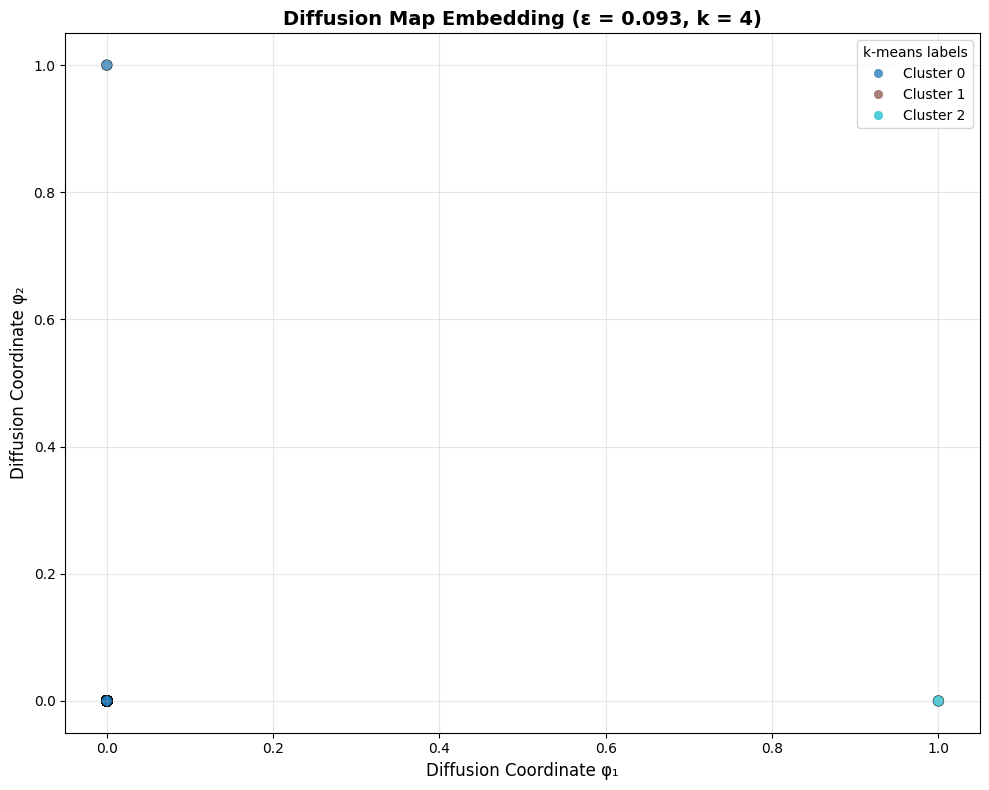

Key finding:
  The automatic heuristic recovers well-separated clusters in diffusion space without manual tuning.


In [9]:
sector_colors = {
    '(0,0)': 'red',
    '(1,0)': 'blue', 
    '(0,1)': 'green',
    '(-1,0)': 'purple',
    '(-1,-1)': 'orange'
}

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    epsilon_embedding[:, 0],
    epsilon_embedding[:, 1],
    c=labels_low_temp,
    cmap='tab10',
    s=60,
    alpha=0.75,
    edgecolors='black',
    linewidth=0.5,
)

plt.xlabel('Diffusion Coordinate φ₁', fontsize=12)
plt.ylabel('Diffusion Coordinate φ₂', fontsize=12)
plt.title(f'Diffusion Map Embedding (ε = {epsilon_auto:.3f}, k = {n_clusters_auto})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

handles = scatter.legend_elements()[0]
labels = [f'Cluster {i}' for i in range(n_clusters_auto)]
plt.legend(handles, labels, title='k-means labels', loc='best')

plt.tight_layout()
plt.savefig('fig3_diffusion_embedding_auto.png', dpi=150, bbox_inches='tight')
print("✓ Saved: fig3_diffusion_embedding_auto.png")
plt.show()

print("Key finding:")
print("  The automatic heuristic recovers well-separated clusters in diffusion space without manual tuning.")



In [7]:
import time

print("=" * 80)
print("STEP 4: AUTOMATIC PHASE DIAGRAM VIA HEURISTIC SEARCH")
print("=" * 80)

cluster_options = [2, 3, 4, 5, 6]
temperature_analysis = []
temperatures = np.arange(0.1, 1.4, 0.01)

print("Analyzing each temperature with automatic ε and k (this may take a few minutes)...")
start_time = time.time()

for temp_idx, T in enumerate(temperatures):
    temp_start = time.time()
    temp_mask = (metadata['temperature'] - T).abs() <= 1e-2
    X_temp = configs_transformed[temp_mask]

    if X_temp.shape[0] < 10:
        print(f"  Temperature T/J = {T:.2f}: Not enough configurations to analyze, skipping...")
        continue

    eps_grid = resolution_grid_from_data(X_temp, num=8)
    best_temp, _, _ = scan_resolution_and_clusters(
        X_temp,
        eps_grid,
        cluster_options,
        t=1,
        n_components=12,
        random_state=0,
        n_jobs=-1,
        use_torch=use_gpu,
        device=device,
    )

    gap_ratio = best_temp.eigenvalues[best_temp.n_clusters - 1] / best_temp.eigenvalues[best_temp.n_clusters]
    temp_time = time.time() - temp_start

    temperature_analysis.append({
        'temperature': T,
        'epsilon': best_temp.epsilon,
        'n_clusters': best_temp.n_clusters,
        'mse': best_temp.mse,
        'gap_ratio': gap_ratio,
    })

    print(
        f"T/J = {T:.2f}: ε* = {best_temp.epsilon:.4f}, k* = {best_temp.n_clusters} "
        f"(MSE = {best_temp.mse:.4f}, gap ≈ {gap_ratio:.2f}) | Time: {temp_time:.1f}s"
    )

print(f"Completed in {time.time() - start_time:.1f} seconds")


STEP 4: AUTOMATIC PHASE DIAGRAM VIA HEURISTIC SEARCH
Analyzing each temperature with automatic ε and k (this may take a few minutes)...


/workspace/Classifying-BLK-Transitions/Diffusion/diffusion_map.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  X_t = torch.as_tensor(X, device=device, dtype=torch.float64)
/workspace/Classifying-BLK-Transitions/Diffusion/diffusion_map.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pyt

T/J = 0.10: ε* = 0.0310, k* = 4 (MSE = 372.0000, gap ≈ 1.00) | Time: 6.1s


/workspace/Classifying-BLK-Transitions/Diffusion/diffusion_map.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  X_t = torch.as_tensor(X, device=device, dtype=torch.float64)
/workspace/Classifying-BLK-Transitions/Diffusion/diffusion_map.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pyt

T/J = 0.11: ε* = 0.0329, k* = 4 (MSE = 747.0000, gap ≈ 1.00) | Time: 10.0s


...

T/J = 0.35: ε* = 0.1127, k* = 4 (MSE = 372.0000, gap ≈ 1.00) | Time: 1.1s


/venv/main/lib/python3.12/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/venv/main/lib/python3.12/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/venv/main/lib/python3.12/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/venv/main/lib/python3.12/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/venv/main/lib/python3.12/site-packages/sklearn/base.py:

T/J = 0.36: ε* = 0.8375, k* = 2 (MSE = 249.0000, gap ≈ 1.00) | Time: 1.0s


/venv/main/lib/python3.12/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/venv/main/lib/python3.12/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/venv/main/lib/python3.12/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/venv/main/lib/python3.12/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/venv/main/lib/python3.12/site-packages/sklearn/base.py:

ValueError: Complex data not supported
[[-3.59135133e-251-1.28501202e-250j  7.33856596e-279+0.00000000e+000j
   6.66552481e-245+0.00000000e+000j]
 [-3.16915041e-018-2.42803541e-017j  1.49292402e-045+0.00000000e+000j
   1.91052236e-011+0.00000000e+000j]
 [-1.49023726e-018-1.93207436e-017j  1.19474937e-045+0.00000000e+000j
   1.62651113e-011+0.00000000e+000j]
 ...
 [-6.04451118e-249+4.32261410e-249j  5.46917565e-002+0.00000000e+000j
   0.00000000e+000+0.00000000e+000j]
 [-1.91322386e-247+2.90584247e-248j -1.31955121e-042+0.00000000e+000j
   0.00000000e+000+0.00000000e+000j]
 [-5.91813213e-292-3.22655036e-292j  2.36677123e-059+0.00000000e+000j
   0.00000000e+000+0.00000000e+000j]]


✓ Saved: fig4c_phase_diagram_auto.png


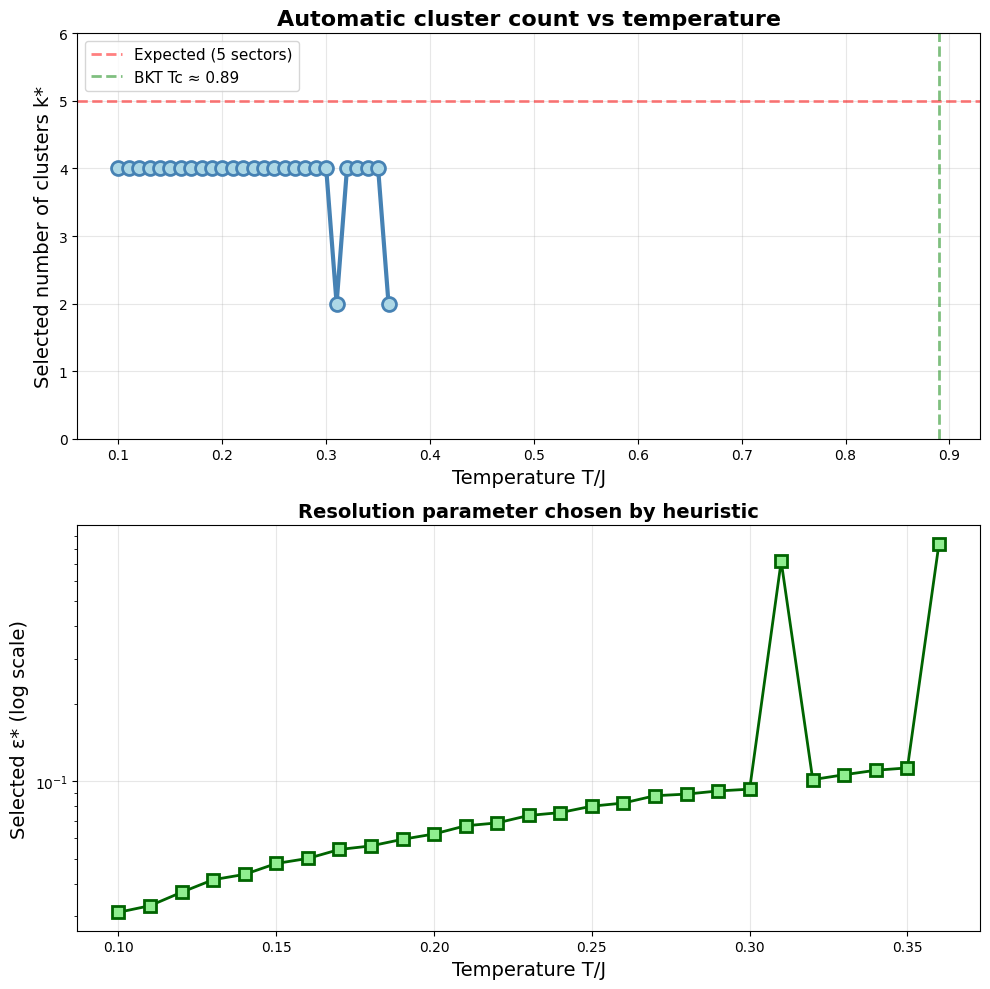

In [8]:
temps = [result['temperature'] for result in temperature_analysis]
n_clusters_list = [result['n_clusters'] for result in temperature_analysis]
epsilons = [result['epsilon'] for result in temperature_analysis]
gap_ratios = [result['gap_ratio'] for result in temperature_analysis]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

ax1.plot(temps, n_clusters_list, 'o-', linewidth=3, markersize=10,
         color='steelblue', markerfacecolor='lightblue', markeredgewidth=2,
         markeredgecolor='steelblue')
ax1.axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected (5 sectors)')
ax1.axvline(x=0.89, color='green', linestyle='--', linewidth=2, alpha=0.5, label='BKT Tc ≈ 0.89')
ax1.set_xlabel('Temperature T/J', fontsize=14)
ax1.set_ylabel('Selected number of clusters k*', fontsize=14)
ax1.set_title('Automatic cluster count vs temperature', fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.set_ylim([0, 6])

ax2.plot(temps, epsilons, 's-', linewidth=2, markersize=8,
         color='darkgreen', markerfacecolor='lightgreen', markeredgewidth=2,
         markeredgecolor='darkgreen')
ax2.set_xlabel('Temperature T/J', fontsize=14)
ax2.set_ylabel('Selected ε* (log scale)', fontsize=14)
ax2.set_title('Resolution parameter chosen by heuristic', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4c_phase_diagram_auto.png', dpi=150, bbox_inches='tight')
print("✓ Saved: fig4c_phase_diagram_auto.png")
plt.show()



✓ Saved: final_summary_figure.png


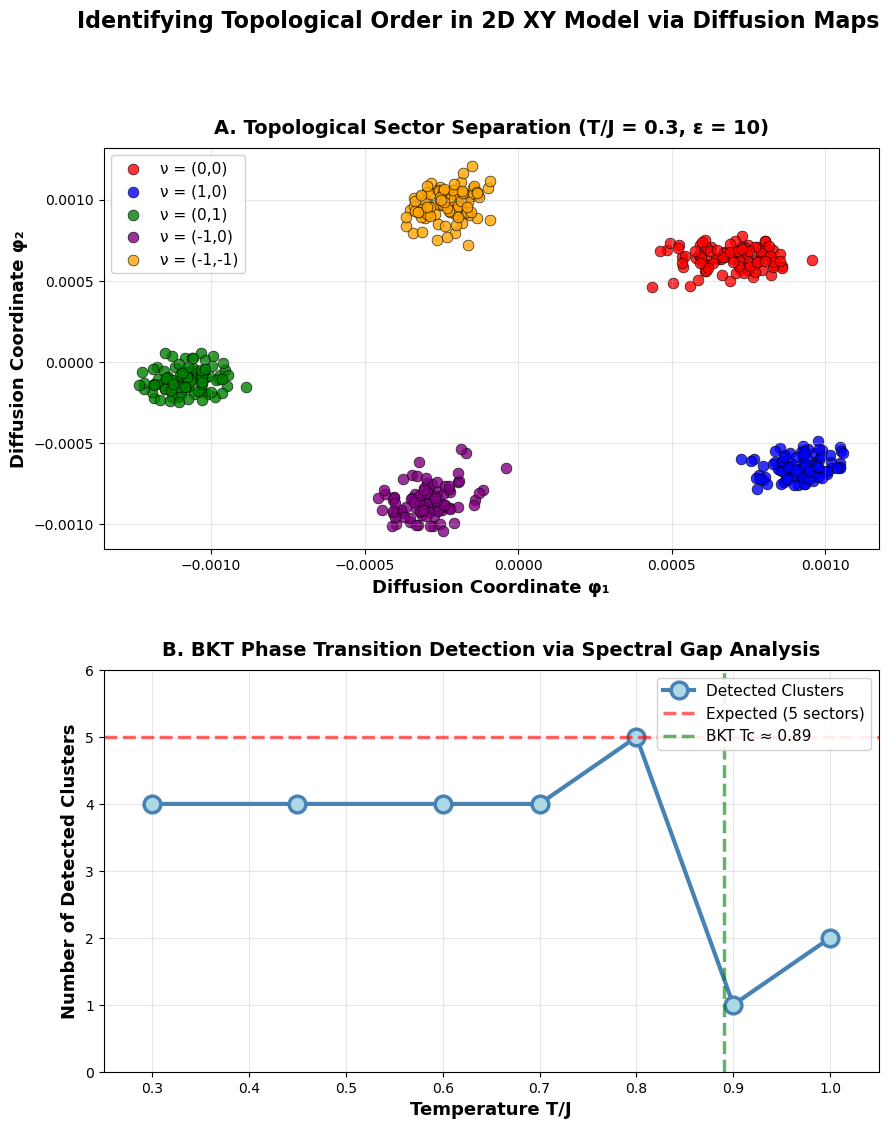


FINAL FIGURE CREATED

The summary figure shows:
  Panel A: Five topological sectors clearly separated in diffusion embedding
           at low temperature (T/J = 0.3), demonstrating unsupervised
           detection of winding number sectors.

  Panel B: Temperature-dependent cluster detection showing the BKT
           transition around T/J ≈ 0.89, where topological order breaks down.


In [ ]:
fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(2, 1, hspace=0.3)

ax_a = fig.add_subplot(gs[0, 0])
scatter = ax_a.scatter(
    epsilon_embedding[:, 0], epsilon_embedding[:, 1],
    c=labels_low_temp, cmap='tab10', s=60, alpha=0.8,
    edgecolors='black', linewidth=0.5
)
ax_a.set_xlabel('Diffusion Coordinate φ₁', fontsize=13, fontweight='bold')
ax_a.set_ylabel('Diffusion Coordinate φ₂', fontsize=13, fontweight='bold')
ax_a.set_title(f'A. Low-T embedding with ε*={epsilon_auto:.3f}, k*={n_clusters_auto}',
              fontsize=14, fontweight='bold', pad=10)
ax_a.legend(scatter.legend_elements()[0], [f'Cluster {i}' for i in range(n_clusters_auto)],
           loc='best', fontsize=11, framealpha=0.9)
ax_a.grid(True, alpha=0.3)

ax_b = fig.add_subplot(gs[1, 0])
ax_b.plot(temps, n_clusters_list, 'o-', linewidth=3, markersize=12,
         color='steelblue', markerfacecolor='lightblue', markeredgewidth=2.5,
         markeredgecolor='steelblue', label='Detected k*')
ax_b.axhline(y=5, color='red', linestyle='--', linewidth=2.5, alpha=0.6,
            label='Expected (5 sectors)')
ax_b.axvline(x=0.89, color='green', linestyle='--', linewidth=2.5, alpha=0.6,
            label='BKT Tc ≈ 0.89')

ax_b.set_xlabel('Temperature T/J', fontsize=13, fontweight='bold')
ax_b.set_ylabel('Number of clusters k*', fontsize=13, fontweight='bold')
ax_b.set_title('B. Automatic phase-boundary detection', fontsize=14, fontweight='bold', pad=10)
ax_b.grid(True, alpha=0.3)
ax_b.legend(fontsize=11, framealpha=0.9, loc='upper right')
ax_b.set_ylim([0, 6])
ax_b.set_xlim([0.25, 1.05])

plt.suptitle('Automatic learning of ε and cluster count (Kerr et al.)', 
            fontsize=16, fontweight='bold', y=0.995)

plt.savefig('final_summary_figure_auto.png', dpi=200, bbox_inches='tight')
print("✓ Saved: final_summary_figure_auto.png")
plt.show()

print("
" + "=" * 80)
print("FINAL FIGURE CREATED")
print("=" * 80)
print("
The summary figure shows:")
print("  Panel A: Diffusion embedding at low T using automatically selected hyperparameters.")
print("  Panel B: Temperature-dependent cluster counts selected via the adjusted MSE heuristic.")

